# Liu-Style Figures

Figures recreating Liu et al. (2025) figure formats using our
category-specific searchmask approach and expanded category set.

**Figures:**
1. Per-ROI Liu distinctiveness boxplots (cf. Liu Fig 3D) — cross-sectional
2. Pairwise dissimilarity trajectories per patient — longitudinal
3. Bootstrapped regression slope test (cf. Liu Fig 5E/J/O) — longitudinal
4. Control reference RDMs


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1: Setup + Load Data
# ═══════════════════════════════════════════════════════════════════════════════

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import ttest_rel

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE     = Path(processed_dir)
LIU_DIR  = BASE / 'group_results' / 'liu_distinctiveness'
GEO_DIR  = BASE / 'group_results' / 'geometry'
FIG_DIR  = BASE / 'group_results' / 'figures' / 'liu_style'
FIG_DIR.mkdir(parents=True, exist_ok=True)

COPE_SET   = 'differential'
EXCLUDE    = ['sub-017']
CATEGORIES = ['face', 'house', 'object', 'word']
ALL_PAIRS  = ['face-house', 'face-object', 'face-word',
              'house-object', 'house-word', 'object-word']

CAT_COLORS = {'face': '#cc0066', 'word': '#ff8800', 'house': '#009900', 'object': '#0077cc'}
PAIR_COLORS = {
    'face-house':  '#668844', 'face-object': '#6644aa', 'face-word':   '#cc4400',
    'house-object':'#008888', 'house-word':  '#88aa00', 'object-word': '#cc6600',
}

plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

# ── Load pairwise correlations ────────────────────────────────────────────
pair_file = LIU_DIR / f'pairwise_correlations_{COPE_SET}.csv'
df_pw = pd.read_csv(pair_file)
df_pw = df_pw[df_pw['category'].isin(CATEGORIES)]
df_pw = df_pw[~df_pw['subject_id'].isin(EXCLUDE)]
if 'subject' in df_pw.columns:
    df_pw = df_pw[~df_pw['subject'].str.contains('017')]
df_pw['session'] = pd.to_numeric(df_pw['session'], errors='coerce').astype(int)

# ── Identify OTC longitudinal patients ────────────────────────────────────
otc_pw = df_pw[df_pw['group'] == 'OTC'].copy()
ctrl_pw = df_pw[df_pw['status'] == 'control'].copy()

# OTC patients with 2+ sessions (intact hemi only)
otc_intact = otc_pw[otc_pw['hemi_label'] == 'intact']
ses_per_sub = otc_intact.groupby('subject_id')['session'].nunique()
otc_long_subs = sorted(ses_per_sub[ses_per_sub >= 2].index.tolist())

print(f'Pairwise correlations: {df_pw["subject_id"].nunique()} subjects')
print(f'OTC longitudinal patients: {len(otc_long_subs)}')
for sub in otc_long_subs:
    sd = otc_intact[otc_intact['subject_id'] == sub]
    sessions = sorted(sd['session'].unique())
    surgery = sd['surgery_side'].iloc[0] if 'surgery_side' in sd.columns else '?'
    sub_code = sd['subject'].iloc[0] if 'subject' in sd.columns else sub
    intact = 'LH' if surgery == 'right' else 'RH'
    print(f'  {sub_code} ({sub}): {len(sessions)} sessions {sessions}, intact {intact}')

print(f'\nControls: {ctrl_pw["subject_id"].nunique()} subjects')

Pairwise correlations: 46 subjects
OTC longitudinal patients: 5
  OTC004 (sub-004): 5 sessions [1, 2, 3, 5, 6], intact LH
  OTC008 (sub-008): 2 sessions [1, 2], intact LH
  OTC010 (sub-010): 2 sessions [2, 3], intact RH
  OTC021 (sub-021): 2 sessions [2, 3], intact RH
  OTC079 (sub-079): 2 sessions [1, 2], intact RH

Controls: 22 subjects


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2: Helper Functions
# ═══════════════════════════════════════════════════════════════════════════════

def build_rdm(df_session_cat):
    """Build a 4x4 RDM from pairwise Fisher r values.
    Input: dataframe filtered to one subject × one session × one hemi,
           with 'pair' and 'fisher_r' columns, category in CATEGORIES.
    Returns: 4x4 numpy array (symmetric, diagonal=0).
    """
    n = len(CATEGORIES)
    rdm = np.full((n, n), np.nan)
    np.fill_diagonal(rdm, 0.0)
    
    for _, row in df_session_cat.iterrows():
        pair = row['pair']
        cats = pair.split('-')
        if cats[0] in CATEGORIES and cats[1] in CATEGORIES:
            i = CATEGORIES.index(cats[0])
            j = CATEGORIES.index(cats[1])
            rdm[i, j] = row['fisher_r']
            rdm[j, i] = row['fisher_r']
    return rdm


def mds_2d(rdm):
    """Classical MDS from a similarity matrix (higher = more similar).
    Convert to dissimilarity first, then MDS.
    """
    # Fisher r: higher = more similar. Convert to distance.
    D = 1 - rdm  # now higher = more different
    np.fill_diagonal(D, 0)
    n = D.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * H @ (D ** 2) @ H
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    coords = eigvecs[:, :2] * np.sqrt(np.maximum(eigvals[:2], 0))
    return coords


def procrustes_align(ref, target):
    """Align target MDS coordinates to reference using Procrustes."""
    from scipy.linalg import orthogonal_procrustes
    # Center both
    ref_c = ref - ref.mean(axis=0)
    tgt_c = target - target.mean(axis=0)
    R, _ = orthogonal_procrustes(tgt_c, ref_c)
    aligned = tgt_c @ R
    return aligned + ref.mean(axis=0)


def get_control_pairwise_stats(ctrl_df, hemi_label):
    """Compute mean and SD of each pairwise Fisher r across controls for a given hemisphere.
    Uses first session per control.
    Returns dict: pair -> (mean, sd, values_array)
    """
    # First session per control
    first_ses = ctrl_df.groupby('subject_id')['session'].min().reset_index().rename(
        columns={'session': 'fs'})
    ctrl_first = ctrl_df.merge(first_ses, on='subject_id')
    ctrl_first = ctrl_first[ctrl_first['session'] == ctrl_first['fs']]
    ctrl_first = ctrl_first[ctrl_first['hemi_label'] == hemi_label]
    
    stats = {}
    for pair in ALL_PAIRS:
        vals = ctrl_first[ctrl_first['pair'] == pair].groupby('subject_id')['fisher_r'].mean().values
        stats[pair] = (np.nanmean(vals), np.nanstd(vals, ddof=1), vals)
    return stats


# Pre-compute control stats per hemisphere
ctrl_stats_lh = get_control_pairwise_stats(ctrl_pw, 'left')
ctrl_stats_rh = get_control_pairwise_stats(ctrl_pw, 'right')

# Also compute control stats across ALL sessions for trajectory bands
def get_control_trajectory_stats(ctrl_df, hemi_label):
    """Per-session control pairwise stats (for trajectory reference).
    Returns dict: pair -> (overall_mean, overall_sd)
    """
    hemi_df = ctrl_df[ctrl_df['hemi_label'] == hemi_label]
    stats = {}
    for pair in ALL_PAIRS:
        # Pool all sessions (each control contributes multiple sessions)
        vals = hemi_df[hemi_df['pair'] == pair]['fisher_r'].values
        stats[pair] = (np.nanmean(vals), np.nanstd(vals, ddof=1))
    return stats

ctrl_traj_lh = get_control_trajectory_stats(ctrl_pw, 'left')
ctrl_traj_rh = get_control_trajectory_stats(ctrl_pw, 'right')

print('Helper functions loaded.')
print(f'Control pairwise stats: LH {len(ctrl_stats_lh)} pairs, RH {len(ctrl_stats_rh)} pairs')

Helper functions loaded.
Control pairwise stats: LH 6 pairs, RH 6 pairs


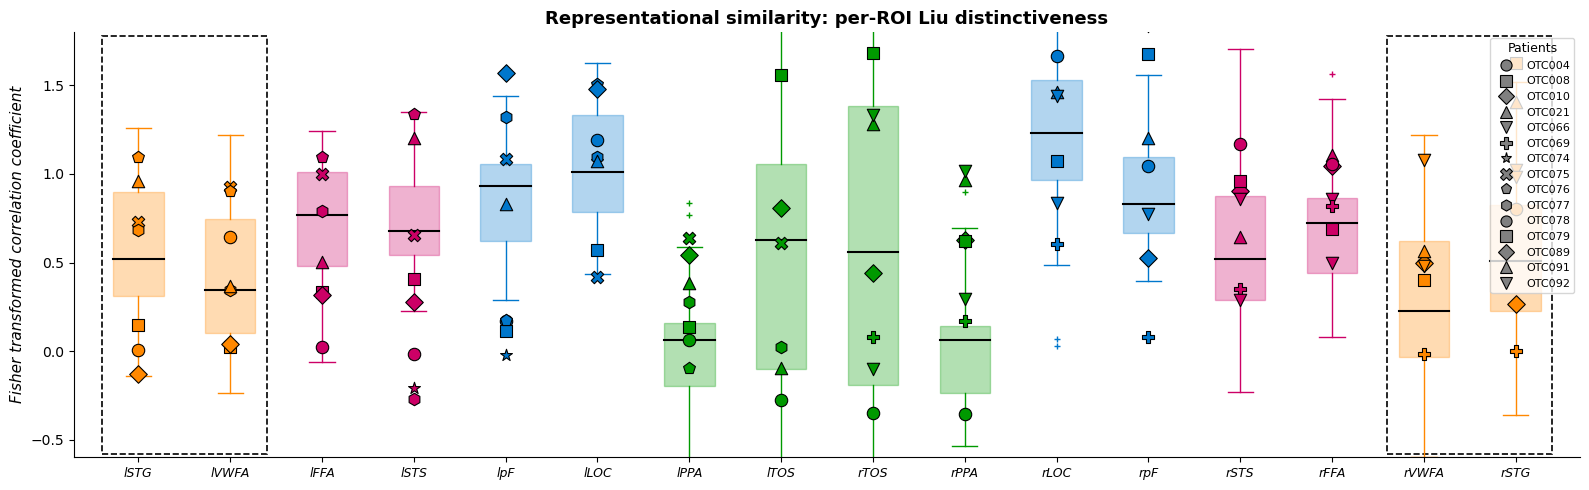

Saved: liu_fig3d_per_roi.png


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# Figure: Per-ROI Liu Distinctiveness (cf. Liu et al. 2025, Fig 3D)
# ═══════════════════════════════════════════════════════════════════════════════
# Boxplots of control distribution per hemisphere-specific ROI.
# Patient markers overlaid using unique shapes per patient (last session).
# Cross-sectional: patients use last available session, controls use first.
# ═══════════════════════════════════════════════════════════════════════════════

# ── Load sub-ROI data ─────────────────────────────────────────────────────
liu_full = pd.read_csv(LIU_DIR / f'liu_distinctiveness_{COPE_SET}.csv')
liu_full = liu_full[~liu_full['subject_id'].isin(EXCLUDE)]
liu_full['ses_num'] = pd.to_numeric(liu_full['session'], errors='coerce').astype(int)

# Controls: first session
ctrl_fs = liu_full[liu_full['status'] == 'control'].copy()
fs = ctrl_fs.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'fs'})
ctrl_fs = ctrl_fs.merge(fs, on='subject_id')
ctrl_fs = ctrl_fs[ctrl_fs['ses_num'] == ctrl_fs['fs']]

# Patients: last session (matching Liu — "last scan session")
pt_full = liu_full[liu_full['group'] == 'OTC'].copy()
ls = pt_full.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'ls'})
pt_full = pt_full.merge(ls, on='subject_id')
pt_full = pt_full[pt_full['ses_num'] == pt_full['ls']]

# ── ROI display order ─────────────────────────────────────────────────────
# Liu order: IFG, STG, VWFA, lFFA, lSTS, lPF, lLOC, lPPA, lTOS, rTOS, rPPA, rLOC, rPF, rSTS, rFFA
# We omit IFG but otherwise match left-to-right layout.

SUB_ROIS_L = [('word_STG', 'left'), ('word_VWFA', 'left'),
              ('face_FFA', 'left'), ('face_STS', 'left'),
              ('object_pF', 'left'), ('object_LOC', 'left'),
              ('house_PPA', 'left'), ('house_TOS', 'left')]

SUB_ROIS_R = [('house_TOS', 'right'), ('house_PPA', 'right'),
              ('object_LOC', 'right'), ('object_pF', 'right'),
              ('face_STS', 'right'), ('face_FFA', 'right'),
              ('word_VWFA', 'right'), ('word_STG', 'right')]

ROI_ORDER = SUB_ROIS_L + SUB_ROIS_R

# Display labels
def roi_label(roi, hemi):
    short = roi.split('_')[-1]
    prefix = 'l' if hemi == 'left' else 'r'
    return f'{prefix}{short}'

# Category colors
ROI_COLORS = {
    'word_STG':    '#ff8800',
    'word_VWFA':   '#ff8800',
    'face_FFA':    '#cc0066',
    'face_STS':    '#cc0066',
    'object_pF':   '#0077cc',
    'object_LOC':  '#0077cc',
    'house_PPA':   '#009900',
    'house_TOS':   '#009900',
}

# Patient markers — unique shape per patient
_marker_cycle = ['o', 's', 'D', '^', 'v', 'P', '*', 'X', 'p', 'h']
PT_MARKERS = {}
for i, sub in enumerate(sorted(pt_full['subject_id'].unique())):
    code = pt_full[pt_full['subject_id'] == sub]['subject'].iloc[0] if 'subject' in pt_full.columns else sub
    PT_MARKERS[sub] = {
        'marker': _marker_cycle[i % len(_marker_cycle)],
        'label':  code,
    }

VCOL = 'liu_distinctiveness'

# ── Build figure ──────────────────────────────────────────────────────────
n_rois = len(ROI_ORDER)
fig, ax = plt.subplots(figsize=(max(16, n_rois * 0.9), 5))

positions = np.arange(n_rois)
xlabels = []

for xi, (roi, hemi) in enumerate(ROI_ORDER):
    color = ROI_COLORS[roi]
    xlabels.append(roi_label(roi, hemi))

    # Control data for this hemi
    ctrl_vals = ctrl_fs[(ctrl_fs['category'] == roi) &
                         (ctrl_fs['hemi_label'] == hemi)][VCOL].dropna().values

    if len(ctrl_vals) == 0:
        continue

    # Boxplot
    bp = ax.boxplot(ctrl_vals, positions=[xi], widths=0.55, patch_artist=True,
                    showfliers=True, flierprops={'marker': '+', 'ms': 5, 'mec': color},
                    medianprops={'color': 'black', 'lw': 1.5},
                    whiskerprops={'color': color}, capprops={'color': color},
                    boxprops={'facecolor': color, 'alpha': 0.3, 'edgecolor': color})

    # Patient markers
    for sub in pt_full['subject_id'].unique():
        sd = pt_full[pt_full['subject_id'] == sub]
        if sd.empty:
            continue

        surgery = sd['surgery_side'].iloc[0] if 'surgery_side' in sd.columns else ''
        intact = 'left' if surgery == 'right' else 'right'

        # Only plot if this ROI's hemisphere matches patient's intact hemi
        if intact != hemi:
            continue

        val = sd[(sd['category'] == roi) & (sd['hemi_label'] == 'intact')][VCOL].values
        if len(val) == 0:
            continue

        mi = PT_MARKERS[sub]
        ax.scatter(xi, val[0], marker=mi['marker'], s=80, zorder=5,
                   edgecolors='black', linewidth=0.8, facecolors=color)

# ── Formatting ────────────────────────────────────────────────────────────
ax.set_xticks(positions)
ax.set_xticklabels(xlabels, fontsize=9, fontstyle='italic')
ax.set_ylabel('Fisher transformed correlation coefficient', fontsize=11, fontstyle='italic')
ax.set_xlim(-0.7, n_rois - 0.3)
ax.set_ylim(-0.6, 1.8)

# Dashed boxes around word ROIs (left) and face ROIs (right) like Liu
# Left word group: lSTG, lVWFA (positions 0, 1)
# Right face group: rSTS, rFFA (positions n_rois-2, n_rois-1)
from matplotlib.patches import FancyBboxPatch
for x_start, x_end in [(0 - 0.4, 1 + 0.4),
                         (n_rois - 2 - 0.4, n_rois - 1 + 0.4)]:
    rect = plt.Rectangle((x_start, ax.get_ylim()[0] + 0.02),
                          x_end - x_start, ax.get_ylim()[1] - ax.get_ylim()[0] - 0.04,
                          fill=False, edgecolor='black', linestyle='--', linewidth=1.2)
    ax.add_patch(rect)

# Legend for patients
handles = [plt.Line2D([0], [0], marker=mi['marker'], color='gray', linestyle='None',
                       ms=8, mec='black', mew=0.8, label=mi['label'])
           for sub, mi in PT_MARKERS.items()]
ax.legend(handles=handles, loc='upper right', fontsize=8, frameon=True,
          title='Patients', title_fontsize=9)

plt.title('Representational similarity: per-ROI Liu distinctiveness',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'liu_fig3d_per_roi.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: liu_fig3d_per_roi.png')


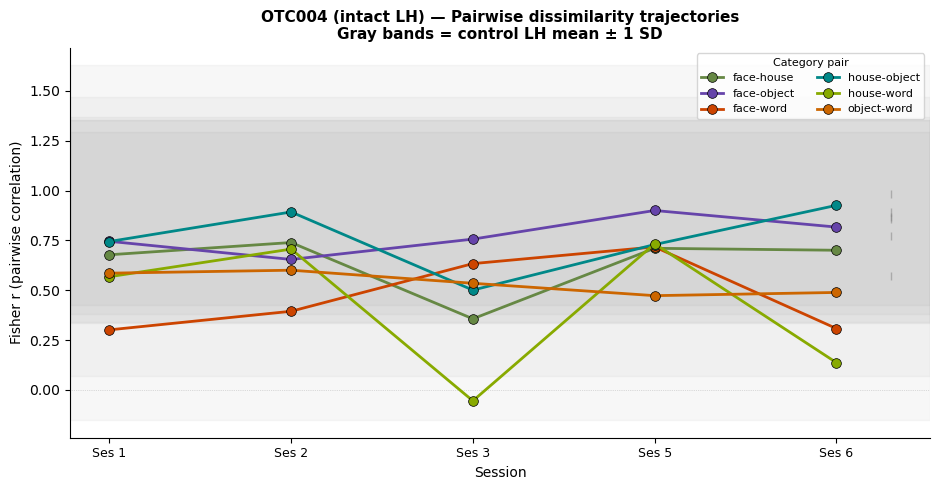

Saved: liu_trajectories_sub-004.png


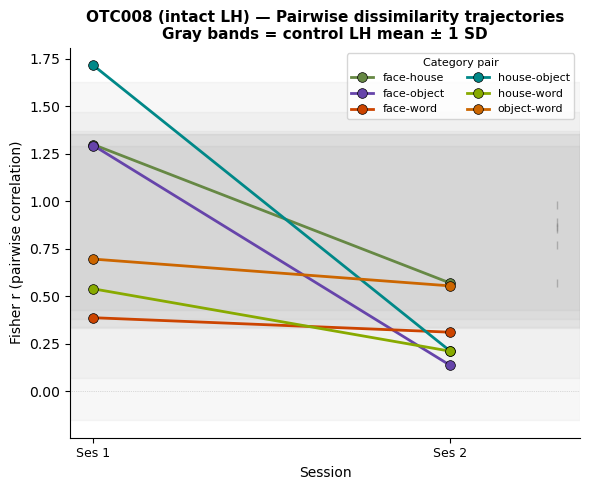

Saved: liu_trajectories_sub-008.png


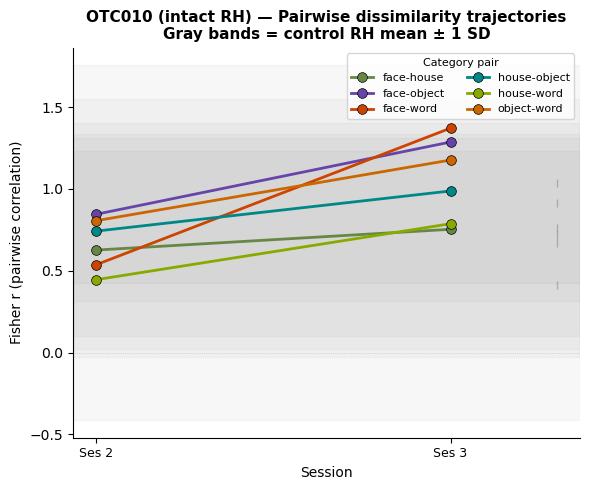

Saved: liu_trajectories_sub-010.png


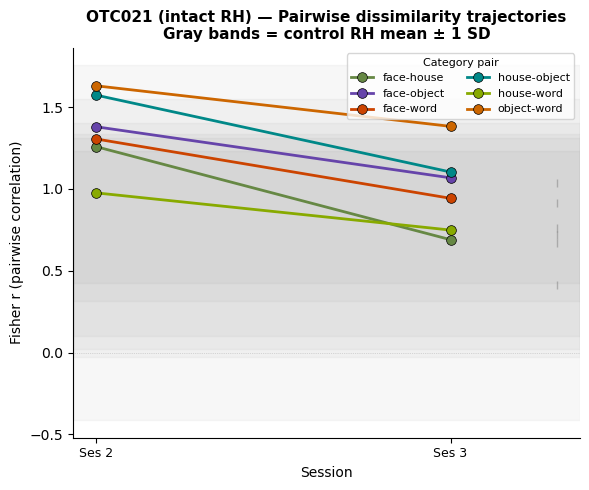

Saved: liu_trajectories_sub-021.png


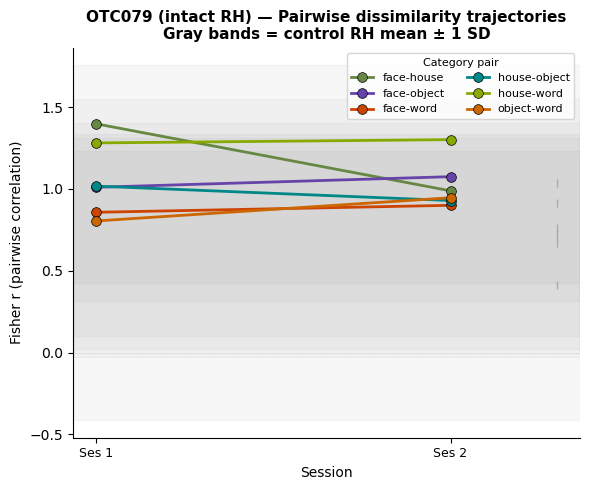

Saved: liu_trajectories_sub-079.png


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5: Figure C — Pairwise Dissimilarity Trajectories per Patient
# ═══════════════════════════════════════════════════════════════════════════════
# All 6 pairwise Fisher r values across sessions.
# Control distribution shown as shaded ±1 SD band.

for sub in otc_long_subs:
    sd = otc_intact[otc_intact['subject_id'] == sub]
    sessions = sorted(sd['session'].unique())
    sub_code = sd['subject'].iloc[0] if 'subject' in sd.columns else sub
    surgery = sd['surgery_side'].iloc[0] if 'surgery_side' in sd.columns else '?'
    intact_hemi = 'left' if surgery == 'right' else 'right'
    intact_label = 'LH' if intact_hemi == 'left' else 'RH'
    
    # Get control stats for matching hemisphere
    ctrl_stats = ctrl_traj_lh if intact_hemi == 'left' else ctrl_traj_rh
    
    fig, ax = plt.subplots(figsize=(max(6, len(sessions) * 1.5 + 2), 5))
    
    # ── Control reference bands ───────────────────────────────────────
    for pair in ALL_PAIRS:
        m, s = ctrl_stats[pair]
        ax.axhspan(m - s, m + s, alpha=0.06, color='gray', zorder=0)
        # Small marker at right edge for control mean
        ax.plot(len(sessions) - 0.7, m, marker='|', color='gray', markersize=6, alpha=0.5)
    
    # ── Patient trajectories ──────────────────────────────────────────
    for pair in ALL_PAIRS:
        pair_vals = []
        for ses in sessions:
            ses_data = sd[(sd['session'] == ses) & (sd['pair'] == pair)]
            if len(ses_data) > 0:
                # Average across ROI categories for this pair
                pair_vals.append(ses_data['fisher_r'].mean())
            else:
                pair_vals.append(np.nan)
        
        color = PAIR_COLORS[pair]
        ax.plot(range(len(sessions)), pair_vals, '-o', color=color,
                linewidth=2, markersize=7, label=pair, zorder=3,
                markeredgecolor='black', markeredgewidth=0.5)
    
    ax.set_xticks(range(len(sessions)))
    ax.set_xticklabels([f'Ses {s}' for s in sessions], fontsize=9)
    ax.set_ylabel('Fisher r (pairwise correlation)', fontsize=10)
    ax.set_xlabel('Session', fontsize=10)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':', alpha=0.5)
    
    ax.legend(loc='upper right', fontsize=8, frameon=True, ncol=2,
              title='Category pair', title_fontsize=8)
    
    plt.title(f'{sub_code} (intact {intact_label}) — Pairwise dissimilarity trajectories\n'
              f'Gray bands = control {intact_label} mean ± 1 SD',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    fname = f'liu_trajectories_{sub}.png'
    plt.savefig(str(FIG_DIR / fname), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

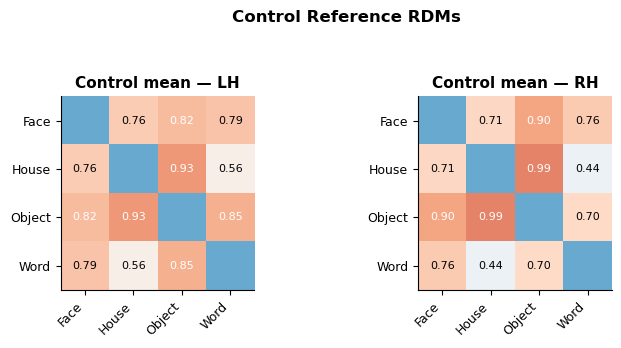

Saved: liu_ctrl_rdm_reference.png


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6: Control Reference RDMs (one per hemisphere)
# ═══════════════════════════════════════════════════════════════════════════════
# Mean control RDM for LH and RH as a visual reference.

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

for hi, (hemi, hemi_label) in enumerate([('left', 'LH'), ('right', 'RH')]):
    ax = axes[hi]
    ctrl_stats = ctrl_stats_lh if hemi == 'left' else ctrl_stats_rh
    
    rdm = np.zeros((4, 4))
    for pair, (m, s, _) in ctrl_stats.items():
        cats = pair.split('-')
        i = CATEGORIES.index(cats[0])
        j = CATEGORIES.index(cats[1])
        rdm[i, j] = m
        rdm[j, i] = m
    
    im = ax.imshow(rdm, cmap='RdBu_r', vmin=-0.5, vmax=1.5, aspect='equal')
    ax.set_xticks(range(4))
    ax.set_xticklabels([c.title() for c in CATEGORIES], fontsize=9, rotation=45, ha='right')
    ax.set_yticks(range(4))
    ax.set_yticklabels([c.title() for c in CATEGORIES], fontsize=9)
    ax.set_title(f'Control mean — {hemi_label}', fontsize=11, fontweight='bold')
    
    for i in range(4):
        for j in range(4):
            if i != j:
                ax.text(j, i, f'{rdm[i,j]:.2f}', ha='center', va='center',
                        fontsize=8, color='black' if abs(rdm[i,j]) < 0.8 else 'white')

#fig.colorbar(im, ax=axes, shrink=0.8, label='Fisher r (mean)')
plt.suptitle('Control Reference RDMs', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.92, 0.92])
plt.savefig(str(FIG_DIR / 'liu_ctrl_rdm_reference.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: liu_ctrl_rdm_reference.png')

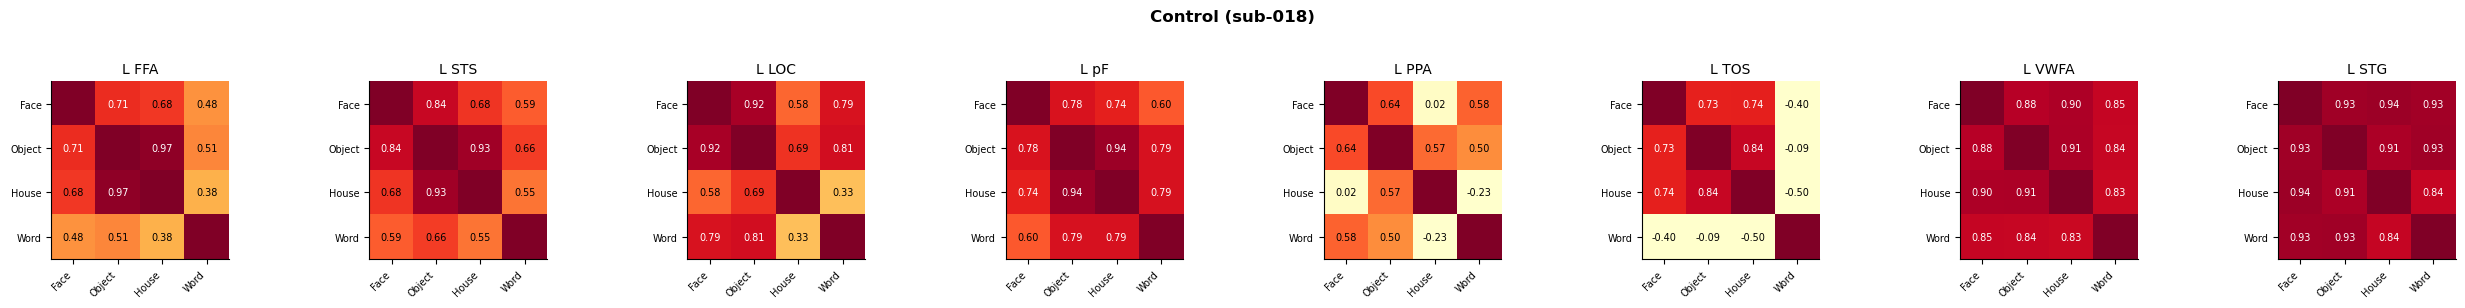

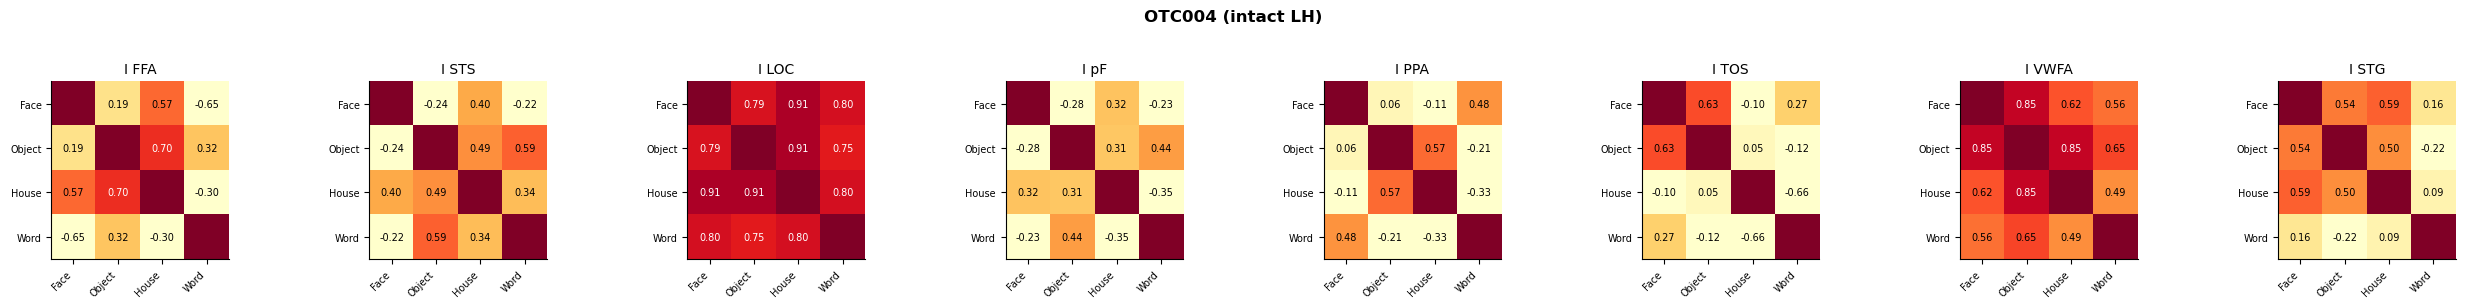

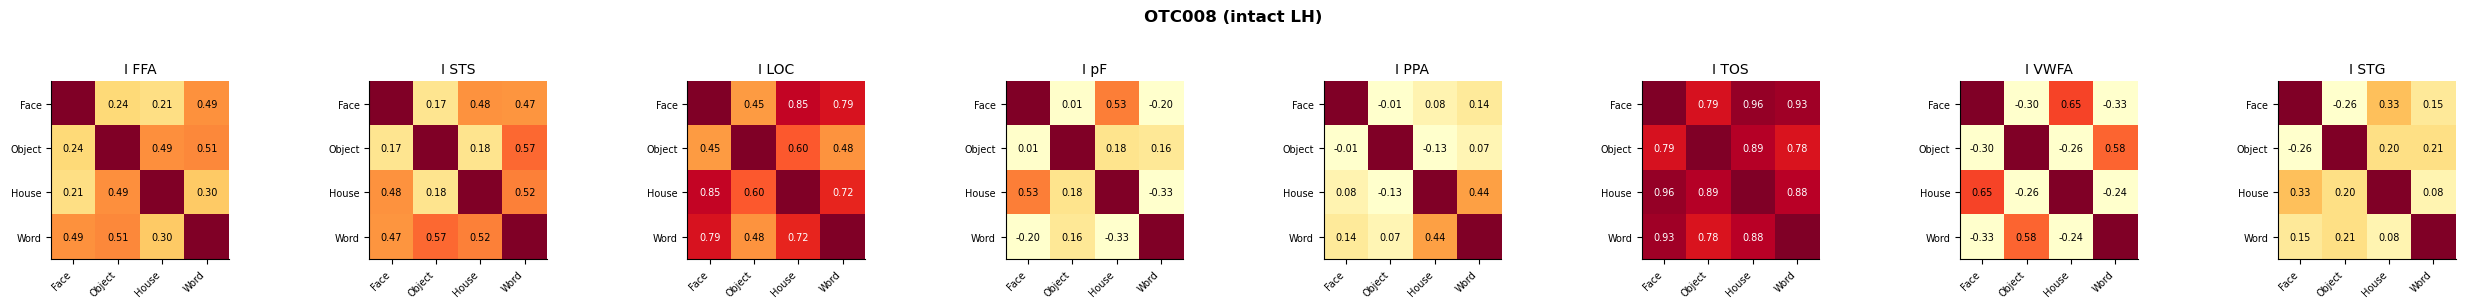

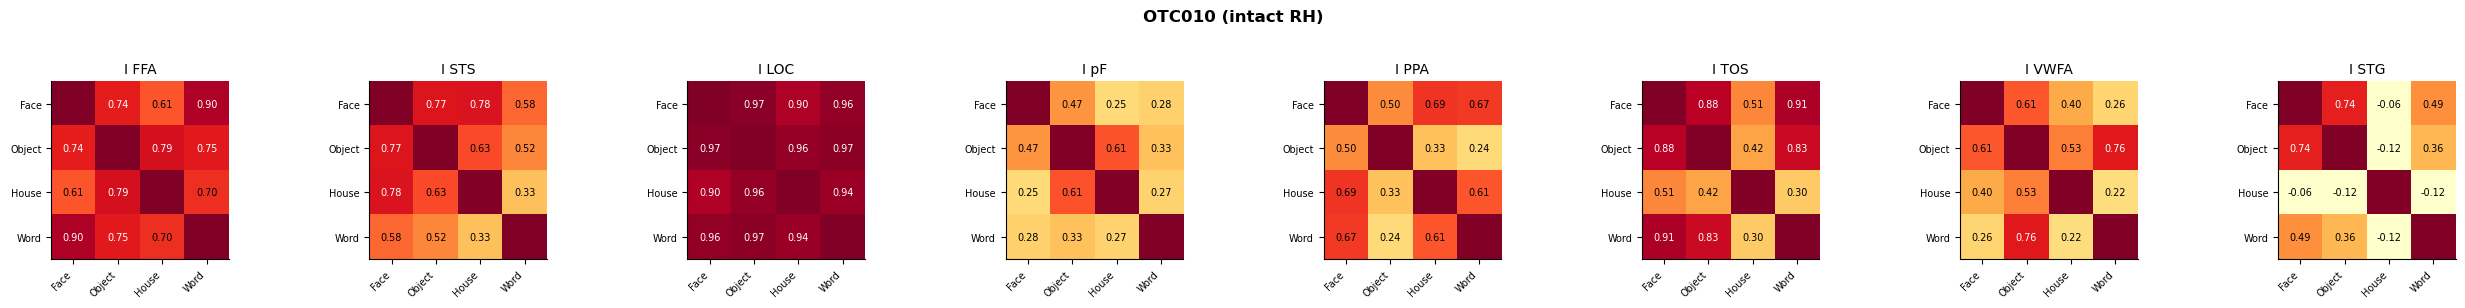

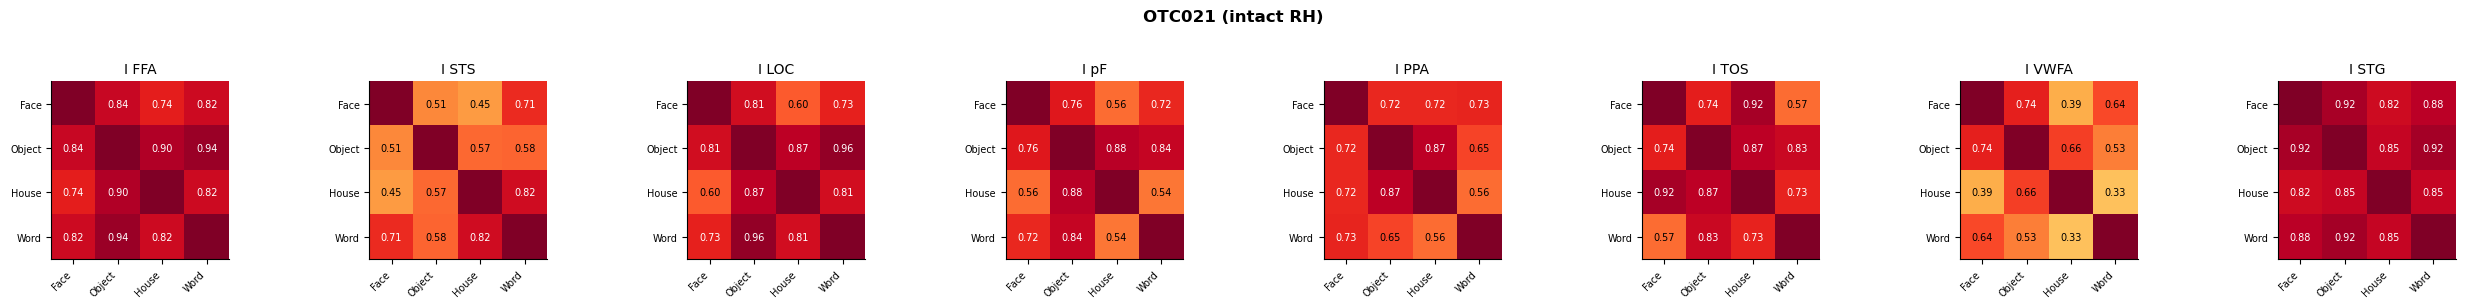

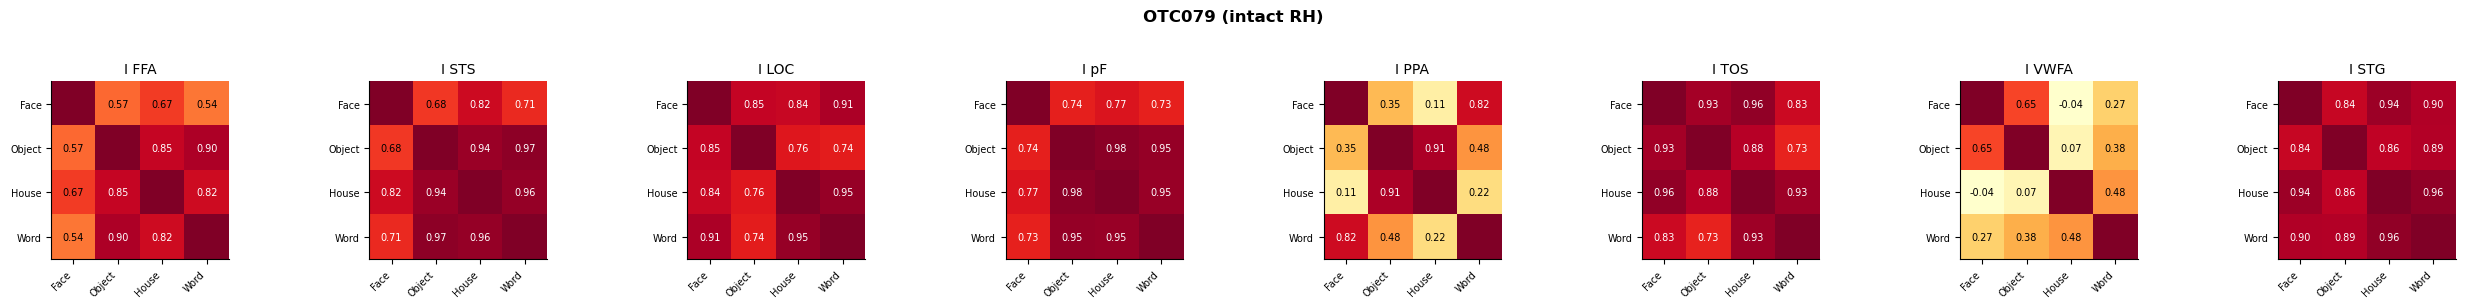

In [8]:
# ── Load pairwise data (if not already loaded) ───────────────────────────
pair_file = LIU_DIR / f'pairwise_correlations_{COPE_SET}.csv'
df_pw = pd.read_csv(pair_file)
#df_pw = df_pw[df_pw['category'].isin(SHOW_ROIS)]

df_pw = df_pw[~df_pw['subject_id'].isin(EXCLUDE)]
df_pw['session'] = pd.to_numeric(df_pw['session'], errors='coerce').astype(int)

ctrl_pw = df_pw[df_pw['status'] == 'control'].copy()
otc_pw = df_pw[df_pw['group'] == 'OTC'].copy()
otc_intact = otc_pw[otc_pw['hemi_label'] == 'intact']

ses_per_sub = otc_intact.groupby('subject_id')['session'].nunique()
otc_long_subs = sorted(ses_per_sub[ses_per_sub >= 2].index.tolist())


# ═══════════════════════════════════════════════════════════════════════════════
# Per-ROI RDM Heatmaps (cf. Liu et al. 2025, Fig 3A/B)
# ═══════════════════════════════════════════════════════════════════════════════
# Each RDM is computed within a SINGLE ROI sphere (not averaged across ROIs).
# Back-transformed to Pearson r for visual comparison with Liu.
# Category order: Face, Object, House, Word (matching Liu).
# ═══════════════════════════════════════════════════════════════════════════════

LIU_ORDER = ['face', 'object', 'house', 'word']

SHOW_ROIS = ['face_FFA', 'face_STS', 'object_LOC', 'object_pF',
             'house_PPA', 'house_TOS', 'word_VWFA', 'word_STG']

def build_rdm_single_roi(df_roi):
    """Build 4x4 RDM from one ROI's pairwise Fisher r, in Liu category order.
    Back-transforms to Pearson r."""
    n = len(LIU_ORDER)
    rdm = np.full((n, n), np.nan)
    np.fill_diagonal(rdm, 1.0)
    for _, row in df_roi.iterrows():
        cats = row['pair'].split('-')
        if cats[0] in LIU_ORDER and cats[1] in LIU_ORDER:
            i = LIU_ORDER.index(cats[0])
            j = LIU_ORDER.index(cats[1])
            rdm[i, j] = np.tanh(row['fisher_r'])
            rdm[j, i] = np.tanh(row['fisher_r'])
    return rdm

# ── Pick subjects/sessions to show ───────────────────────────────────────
# Controls: one example (first control, first session)
ctrl_ex = ctrl_pw[ctrl_pw['subject_id'] == ctrl_pw['subject_id'].unique()[0]]
ctrl_ex = ctrl_ex[ctrl_ex['session'] == ctrl_ex['session'].min()]

# Patients: last session per OTC longitudinal patient
pt_examples = []
for sub in otc_long_subs:
    sd = otc_intact[otc_intact['subject_id'] == sub]
    last_ses = sd['session'].max()
    sd_last = sd[sd['session'] == last_ses]
    sub_code = sd['subject'].iloc[0] if 'subject' in sd.columns else sub
    surgery = sd['surgery_side'].iloc[0] if 'surgery_side' in sd.columns else '?'
    intact = 'LH' if surgery == 'right' else 'RH'
    pt_examples.append({'sub': sub, 'code': sub_code, 'intact': intact,
                        'data': sd_last})

# ── Plot: one row per subject, one column per ROI ─────────────────────────
subjects = [{'label': f'Control ({ctrl_ex["subject_id"].iloc[0]})',
             'data': ctrl_ex}] + \
           [{'label': f'{p["code"]} (intact {p["intact"]})',
             'data': p['data']} for p in pt_examples]

for subj in subjects:
    df_sub = subj['data']
    available_rois = [r for r in SHOW_ROIS if r in df_sub['category'].values]
    if not available_rois:
        continue

    n_rois = len(available_rois)
    fig, axes = plt.subplots(1, n_rois, figsize=(3.2 * n_rois, 3))
    if n_rois == 1:
        axes = [axes]

    for ri, roi in enumerate(available_rois):
        ax = axes[ri]
        roi_data = df_sub[df_sub['category'] == roi]
        rdm = build_rdm_single_roi(roi_data)

        im = ax.imshow(rdm, cmap='YlOrRd', vmin=0, vmax=1, aspect='equal')
        ax.set_xticks(range(4))
        ax.set_xticklabels([c.title() for c in LIU_ORDER], fontsize=7,
                           rotation=45, ha='right')
        ax.set_yticks(range(4))
        ax.set_yticklabels([c.title() for c in LIU_ORDER], fontsize=7)

        hemi = roi_data['hemi_label'].iloc[0] if len(roi_data) > 0 else '?'
        h_str = hemi[0].upper() if isinstance(hemi, str) else '?'
        ax.set_title(f'{h_str} {roi.split("_")[-1]}', fontsize=10)

        for i in range(4):
            for j in range(4):
                if not np.isnan(rdm[i, j]) and i != j:
                    ax.text(j, i, f'{rdm[i,j]:.2f}', ha='center', va='center',
                            fontsize=7, color='black' if rdm[i,j] < 0.7 else 'white')

    plt.suptitle(subj['label'], fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()